In [1]:
!pip install transformers

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

/Users/maheswarareddyp/.pyenv/versions/3.10.17/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# dtype selection for Apple Silicon
if device.type == "mps":
    # Try BF16 (best for M3/M4), fallback to FP16
    try:
        torch.zeros(1, dtype=torch.bfloat16, device="mps")
        dtype = torch.bfloat16
    except Exception:
        dtype = torch.float16
else:
    dtype = torch.float32


In [5]:
device

device(type='mps')

In [6]:
dtype

torch.bfloat16

In [8]:
model_name = "Qwen/Qwen2.5-0.5B"

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

In [9]:
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=dtype,
    trust_remote_code=True
    ).to(device)

In [10]:
model.eval()

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2

In [12]:
# Qwen configs sometimes have no pad_token set; safest is EOS
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
if model.config.pad_token_id is None:
    model.config.pad_token_id = tokenizer.eos_token_id

print("Loaded tokenizer:", tokenizer.name_or_path)
print("Loaded model:", model.config._name_or_path)
print("Device:", device, "| dtype:", dtype)

Loaded tokenizer: Qwen/Qwen2.5-0.5B
Loaded model: Qwen/Qwen2.5-0.5B
Device: mps | dtype: torch.bfloat16


In [13]:
def pretty_token(t: str) -> str:
    # Byte-level BPE style space/newline markers
    t = t.replace("Ġ", " ")
    t = t.replace("Ċ", "\\n")
    return t

In [14]:
def get_next_token_topk(prompt, top_k=10):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits[0, -1]     # (vocab,)
    probs = F.softmax(logits, dim=-1)  # (vocab,)

    top_probs, top_ids = torch.topk(probs, top_k)
    tokens = tokenizer.convert_ids_to_tokens(top_ids.tolist())
    pretty = [pretty_token(t) for t in tokens]

    return pretty, top_probs.detach().cpu().tolist()

In [15]:
# Plot helper
def plot_topk(tokens_a, probs_a, tokens_b, probs_b, title_a, title_b):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

    axes[0].bar(range(len(tokens_a)), probs_a)
    axes[0].set_xticks(range(len(tokens_a)))
    axes[0].set_xticklabels(tokens_a, rotation=60, ha="right")
    axes[0].set_title(title_a)
    axes[0].set_ylabel("Probability")

    axes[1].bar(range(len(tokens_b)), probs_b)
    axes[1].set_xticks(range(len(tokens_b)))
    axes[1].set_xticklabels(tokens_b, rotation=60, ha="right")
    axes[1].set_title(title_b)

    plt.show()

In [16]:
# Prompts differ by ONE token
prompt_a = "The capital of France is"
prompt_b = "The capital of Germany is"

top_k = 10
tokens_a, probs_a = get_next_token_topk(prompt_a, top_k=top_k)
tokens_b, probs_b = get_next_token_topk(prompt_b, top_k=top_k)


Prompt A: The capital of France is
             Paris  0.3438
            ______  0.1118
              ____  0.0598
                __  0.0527
               :\n  0.0466
           located  0.0320
                \n  0.0265
               the  0.0265
                 (  0.0194
             :\n\n  0.0171

Prompt B: The capital of Germany is
            Berlin  0.1719
                __  0.1182
            ______  0.0923
              ____  0.0493
               the  0.0435
           located  0.0435
           Hamburg  0.0317
               :\n  0.0299
                 (  0.0264
         Frankfurt  0.0264


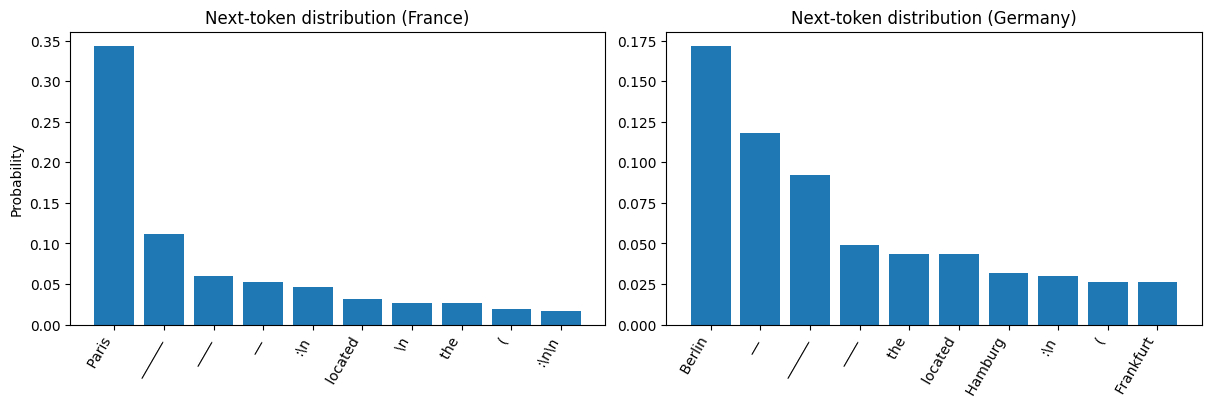

In [17]:
print("\nPrompt A:", prompt_a)
for t, p in zip(tokens_a, probs_a):
    print(f"{t:>18}  {p:.4f}")

print("\nPrompt B:", prompt_b)
for t, p in zip(tokens_b, probs_b):
    print(f"{t:>18}  {p:.4f}")

plot_topk(
    tokens_a, probs_a,
    tokens_b, probs_b,
    title_a="Next-token distribution (France)",
    title_b="Next-token distribution (Germany)"
)

In [18]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

BASE_ID = "Qwen/Qwen2.5-0.5B"
INST_ID = "Qwen/Qwen2.5-0.5B-Instruct"

def load(model_id):
    tok = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
    mdl = AutoModelForCausalLM.from_pretrained(
        model_id,
        dtype="auto",
        device_map="auto",
        trust_remote_code=True
    )
    if tok.pad_token_id is None:
        tok.pad_token = tok.eos_token
    return tok, mdl

base_tok, base_m = load(BASE_ID)
inst_tok, inst_m = load(INST_ID)

@torch.inference_mode()
def gen_base(prompt, max_new_tokens=80):
    x = base_tok(prompt, return_tensors="pt").to(base_m.device)
    y = base_m.generate(
        **x,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        pad_token_id=base_tok.eos_token_id,
    )
    return base_tok.decode(y[0], skip_special_tokens=True)

@torch.inference_mode()
def gen_instruct(user_prompt, max_new_tokens=80):
    # Proper chat formatting for instruct model
    chat = [{"role": "user", "content": user_prompt}]
    prompt = inst_tok.apply_chat_template(chat, tokenize=False, add_generation_prompt=True)
    x = inst_tok(prompt, return_tensors="pt").to(inst_m.device)
    y = inst_m.generate(
        **x,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        pad_token_id=inst_tok.eos_token_id,
    )
    out = inst_tok.decode(y[0], skip_special_tokens=True)
    # Trim the echoed prompt if present
    return out[len(inst_tok.decode(x["input_ids"][0], skip_special_tokens=True)) :].strip()

tests = [
    "How do I make a pizza?",
    "Write a haiku about summer.",
]

for p in tests:
    print("\n" + "="*90)
    print("PROMPT:", p)
    print("-"*90)
    print("BASE (pretrained):")
    print(gen_base(p))
    print("-"*90)
    print("INSTRUCT (fine-tuned):")
    print(gen_instruct(p))



PROMPT: How do I make a pizza?
------------------------------------------------------------------------------------------
BASE (pretrained):


/Users/maheswarareddyp/.pyenv/versions/3.10.17/lib/python3.10/site-packages/transformers/pytorch_utils.py:339: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_elements = torch.tensor(test_elements)


How do I make a pizza? To make a pizza, you'll need a pizza dough, cheese, and other ingredients. Here's a step-by-step guide:

1. Gather your ingredients: You'll need a pizza dough, cheese, and other ingredients like pepperoni, mushrooms, onions, olives, and any other toppings you want to add.

2. Prepare the pizza dough: Preheat your oven and line a baking sheet
------------------------------------------------------------------------------------------
INSTRUCT (fine-tuned):
Making a delicious pizza is a fun and rewarding experience! Here’s a basic guide to help you get started:

### Ingredients:
- 2 1/4 pounds of flour (50g)
- 3 tablespoons of salt (7g)
- 1 teaspoon of sugar (0.6g)
- 1 teaspoon of baking powder (0.9g)
- 1 cup of

PROMPT: Write a haiku about summer.
------------------------------------------------------------------------------------------
BASE (pretrained):
Write a haiku about summer. Summer breeze whispers,
Sunbeams dance on the horizon,
Leaves rustle in the breeze.
